In [1]:
import os, librosa, numpy as np
from pathlib import Path

import tensorflow.keras as keras
from keras.layers import Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATASET_PATH = Path(r"D:\MSc\3. Spring 2026\CSE715\Project\wavs3sec")
OUTPUT_DIR = Path("mfcc_40")

In [3]:
DATASET_PATH.exists() # must be true

True

In [4]:
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

In [5]:
MODEL_PATH   = "best_model.keras"
N_MFCC       = 40
SAMPLE_RATE  = 22050
DURATION     = 3
SAMPLES      = SAMPLE_RATE * DURATION
NUM_CLASSES  = 8
GENRE_NAMES  = ["Adhunik", "Folk", "Hiphop", "Indie",
                "Islamic", "Metal", "Pop", "Rock"]

In [6]:
def extract_mfcc_to_npy(DATASET_PATH, output_dir, n_mfcc=N_MFCC, sr=SAMPLE_RATE, duration=DURATION):
    os.makedirs(output_dir, exist_ok=True)
    
    all_mfcc   = []
    all_labels = []
    
    for genre in sorted(os.listdir(DATASET_PATH)):
        genre_path = os.path.join(DATASET_PATH, genre)
        if not os.path.isdir(genre_path):
            continue
        print(f"Processing: {genre}")
        
        for fname in os.listdir(genre_path):
            if not fname.endswith('.wav'):
                continue
            fpath = os.path.join(genre_path, fname)
            try:
                y, _ = librosa.load(fpath, sr=sr, duration=duration)
                if len(y) < sr * duration:
                    y = np.pad(y, (0, sr * duration - len(y)))
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T  # (timesteps, 40)
                all_mfcc.append(mfcc)
                all_labels.append(genre)
            except Exception as e:
                print(f"  Skipping {fname}: {e}")
    
    X = np.array(all_mfcc)        # (N, timesteps, 40)
    y = np.array(all_labels)      # (N,)
    
    np.save(os.path.join(output_dir, "X_mfcc.npy"), X)
    np.save(os.path.join(output_dir, "labels.npy"), y)
    print(f"Saved X: {X.shape}, y: {y.shape} → {output_dir}")

In [7]:
extract_mfcc_to_npy(DATASET_PATH=DATASET_PATH, output_dir=OUTPUT_DIR)

Processing: Adhunik


d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing: Folk
Processing: Hiphop
Processing: Indie
Processing: Islamic
Processing: Metal
Processing: Pop
Processing: Rock
Saved X: (16170, 130, 40), y: (16170,) → mfcc_40


In [8]:
def load_data(output_dir):
    X = np.load(os.path.join(output_dir, "X_mfcc.npy"))
    y = np.load(os.path.join(output_dir, "labels.npy"))
    return X, y

In [9]:
def prepare_datasets(test_size=0.1, validation_size=0.15):
    X, y = load_data(OUTPUT_DIR)
    
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)   # string genres → integers
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=validation_size)
    
    # Add channel dimension
    X_train = X_train[..., np.newaxis]
    X_val   = X_val[..., np.newaxis]
    X_test  = X_test[..., np.newaxis]
    
    # One-hot encode train and val; keep y_test as integers (their approach)
    y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
    y_val   = to_categorical(y_val,   num_classes=NUM_CLASSES)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, label_encoder

In [10]:
def build_model(input_shape):
    model = keras.Sequential([
        keras.layers.Conv2D(32,  (3,3), activation='relu', input_shape=input_shape),
        keras.layers.MaxPooling2D(2, padding='valid'),
        
        keras.layers.Conv2D(128, (3,3), activation='relu'),
        keras.layers.MaxPooling2D(2, padding='valid'),
        Dropout(0.3),
        
        keras.layers.Conv2D(128, (3,3), activation='relu'),
        keras.layers.MaxPooling2D(2, padding='valid'),
        Dropout(0.3),
        
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

In [11]:
X_train, X_val, X_test, y_train, y_val, y_test_int, label_encoder = prepare_datasets()

In [12]:
input_shape = (X_train.shape[1], X_train.shape[2], 1)
model = build_model(input_shape)

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',   # kept as-is to match their training
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 38, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 17, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 29, 6, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 3, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 3, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,048 (996.28 KB)

 Trainable params: 255,048 (996.28 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', mode='min', patience=10,
                  min_delta=0.0001, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1)
]

In [15]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    batch_size=32, epochs=400,
                    callbacks=callbacks)

Epoch 1/400
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3200 - loss: 0.3533
Epoch 1: val_accuracy improved from None to 0.53504, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
387/387 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.4353 - loss: 0.2992 - val_accuracy: 0.5350 - val_loss: 0.2593
Epoch 2/400
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5691 - loss: 0.2379
Epoch 2: val_accuracy improved from 0.53504 to 0.59689, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
387/387 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5821 - loss: 0.2319 - val_accuracy: 0.5969 - val_loss: 0.2353
Epoch 3/400
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6099 - loss: 0.2181
Epoch 3: val_accuracy improved from 0.59689 to 0.61933, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
387/387 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.6129 - loss: 0.2169 -

51/51 - 1s - 11ms/step - accuracy: 0.8275 - loss: 0.1096

Test accuracy: 0.8275
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

     Adhunik       0.92      0.86      0.89       228
        Folk       0.76      0.89      0.82       228
      Hiphop       0.91      0.96      0.93       167
       Indie       0.78      0.72      0.75       218
     Islamic       0.93      0.96      0.94       199
       Metal       0.86      0.93      0.89       184
         Pop       0.73      0.62      0.67       232
        Rock       0.73      0.71      0.72       161

    accuracy                           0.83      1617
   macro avg       0.83      0.83      0.83      1617
weighted avg       0.83      0.83      0.82      1617



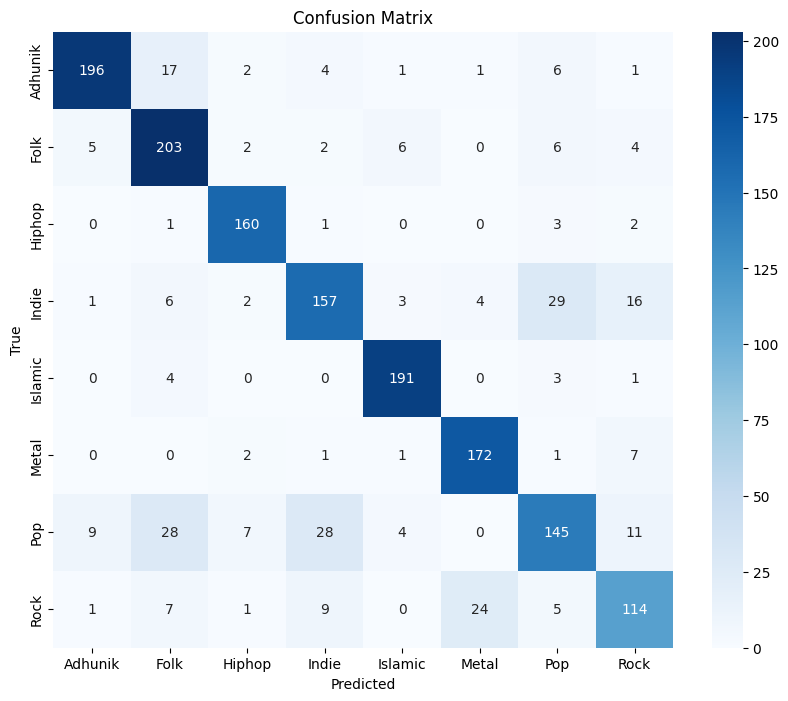

In [16]:
# ── STEP 6: EVALUATE ─────────────────────────────────────────────────────────
y_test_ohe = to_categorical(y_test_int, num_classes=NUM_CLASSES)
test_loss, test_acc = model.evaluate(X_test, y_test_ohe, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

y_pred_classes = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test_int, y_pred_classes, target_names=GENRE_NAMES))

cm = confusion_matrix(y_test_int, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png")
plt.show()

In [17]:
# ── STEP 7: INFERENCE ON YOUR THIRD DATASET ──────────────────────────────────
import pandas as pd

best_model = keras.models.load_model(MODEL_PATH)

def predict_genre(wav_path, model, n_mfcc=40, sr=22050, duration=30):
    y, _ = librosa.load(wav_path, sr=sr, duration=duration)
    if len(y) < sr * duration:
        y = np.pad(y, (0, sr * duration - len(y)))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T
    mfcc = mfcc[np.newaxis, ..., np.newaxis]   # (1, timesteps, 40, 1)
    pred = model.predict(mfcc, verbose=0)
    return GENRE_NAMES[np.argmax(pred)]

results = []
THIRD_DATASET_DIR = r"D:\MSc\3. Spring 2026\CSE715\Project\yt autocap dataset\audio"
for fname in os.listdir(THIRD_DATASET_DIR):
    if fname.endswith('.wav'):
        fpath = os.path.join(THIRD_DATASET_DIR, fname)
        genre = predict_genre(fpath, best_model)
        results.append({"file": fname, "genre": genre})
        print(f"{fname} → {genre}")

-Bfa-aVa7MU_seg_00001.wav → Islamic
-Bfa-aVa7MU_seg_00002.wav → Islamic
-Bfa-aVa7MU_seg_00003.wav → Islamic
-Bfa-aVa7MU_seg_00004.wav → Islamic
-Bfa-aVa7MU_seg_00005.wav → Islamic
-Bfa-aVa7MU_seg_00006.wav → Islamic
-Bfa-aVa7MU_seg_00007.wav → Islamic
-Bfa-aVa7MU_seg_00008.wav → Islamic
-Bfa-aVa7MU_seg_00009.wav → Islamic
-ph4mykFp9I_seg_00001.wav → Islamic
-ph4mykFp9I_seg_00002.wav → Rock
-ph4mykFp9I_seg_00003.wav → Islamic
-ph4mykFp9I_seg_00004.wav → Rock
-ph4mykFp9I_seg_00005.wav → Islamic
-ph4mykFp9I_seg_00006.wav → Metal
-ph4mykFp9I_seg_00007.wav → Metal
-ph4mykFp9I_seg_00008.wav → Metal
-ph4mykFp9I_seg_00009.wav → Islamic
-ph4mykFp9I_seg_00010.wav → Metal
-ph4mykFp9I_seg_00011.wav → Islamic
-ph4mykFp9I_seg_00012.wav → Metal
-ph4mykFp9I_seg_00013.wav → Islamic
-ph4mykFp9I_seg_00014.wav → Islamic
-ph4mykFp9I_seg_00015.wav → Metal
-ph4mykFp9I_seg_00016.wav → Islamic
8dLOs8LK4OQ_seg_00001.wav → Islamic
8dLOs8LK4OQ_seg_00002.wav → Islamic
8dLOs8LK4OQ_seg_00003.wav → Islamic
8dLOs8LK4O

In [18]:
results = pd.DataFrame(results)
results["genre"].unique()

<StringArray>
['Islamic', 'Rock', 'Metal']
Length: 3, dtype: str

In [ ]:
pd.DataFrame(results).to_csv("genre_labels.csv", index=False)
print("Done. Saved to genre_labels.csv")

In [8]:
import os
import numpy as np
import librosa
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# ── CONFIG ───────────────────────────────────────────────────────────────────
MODEL_PATH   = "best_model.hdf5"
N_MFCC       = 40
SR           = 22050
DURATION     = 3
GENRE_NAMES  = ["Adhunik", "Folk", "Hiphop", "Indie",
                "Islamic", "Metal", "Pop", "Rock"]

# ── LOAD MODEL ───────────────────────────────────────────────────────────────
model = keras.models.load_model(MODEL_PATH)
model.summary()   # inspect — does the architecture match what we expect?

# ── EXTRACT MFCCs AND RUN INFERENCE ──────────────────────────────────────────
all_preds  = []
all_labels = []

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 38, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 17, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 29, 6, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 6, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 6, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,050 (996.29 KB)

 Trainable params: 255,048 (996.28 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [9]:
for genre in sorted(os.listdir(DATASET_PATH)):
    genre_path = os.path.join(DATASET_PATH, genre)
    if not os.path.isdir(genre_path):
        continue
    print(f"Processing: {genre}")

    for fname in os.listdir(genre_path):
        if not fname.endswith('.wav'):
            continue
        fpath = os.path.join(genre_path, fname)
        try:
            y, _ = librosa.load(fpath, sr=SR, duration=DURATION)
            if len(y) < SR * DURATION:
                y = np.pad(y, (0, SR * DURATION - len(y)))
            mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC).T  # (timesteps, 40)
            mfcc = mfcc[np.newaxis, ..., np.newaxis]                   # (1, timesteps, 40, 1)

            pred = model.predict(mfcc, verbose=0)
            all_preds.append(np.argmax(pred))
            all_labels.append(GENRE_NAMES.index(genre))
        except Exception as e:
            print(f"  Skipping {fname}: {e}")

Processing: Adhunik
Processing: Folk
Processing: Hiphop
Processing: Indie
Processing: Islamic
Processing: Metal
Processing: Pop
Processing: Rock


In [10]:
print("Model expects:", model.input_shape)   # e.g. (None, 1292, 40, 1)
print("Your MFCC shape:", mfcc.shape)        # should match

Model expects: (None, 130, 40, 1)
Your MFCC shape: (1, 130, 40, 1)


In [11]:
# ── RESULTS ──────────────────────────────────────────────────────────────────
acc = accuracy_score(all_labels, all_preds)
print(f"\nOverall Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(classification_report(all_labels, all_preds, target_names=GENRE_NAMES))


Overall Accuracy: 0.7375 (73.75%)
              precision    recall  f1-score   support

     Adhunik       0.67      0.20      0.31        10
        Folk       0.83      1.00      0.91        10
      Hiphop       1.00      1.00      1.00        10
       Indie       0.75      0.60      0.67        10
     Islamic       0.67      1.00      0.80        10
       Metal       1.00      1.00      1.00        10
         Pop       0.15      0.20      0.17        10
        Rock       1.00      0.90      0.95        10

    accuracy                           0.74        80
   macro avg       0.76      0.74      0.73        80
weighted avg       0.76      0.74      0.73        80



In [12]:
def prepare_datasets(test_size=0.1, validation_size=0.15):
    X, y = load_data(JSON_PATH)
    
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)   # string genres → integers
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=validation_size)
    
    # Add channel dimension
    X_train = X_train[..., np.newaxis]
    X_val   = X_val[..., np.newaxis]
    X_test  = X_test[..., np.newaxis]
    
    # One-hot encode train and val; keep y_test as integers (their approach)
    y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
    y_val   = to_categorical(y_val,   num_classes=NUM_CLASSES)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, label_encoder

In [13]:
import os
import json
import numpy as np
import librosa
import tensorflow.keras as keras
from keras.layers import Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns




# ── STEP 3: PREPARE DATASETS (exact replica of their prepare_datasets) ───────



# ── STEP 4: BUILD MODEL (exact replica) ─────────────────────────────────────
def build_model(input_shape):
    model = keras.Sequential([
        keras.layers.Conv2D(32,  (3,3), activation='relu', input_shape=input_shape),
        keras.layers.MaxPooling2D(2, padding='valid'),
        
        keras.layers.Conv2D(128, (3,3), activation='relu'),
        keras.layers.MaxPooling2D(2, padding='valid'),
        Dropout(0.3),
        
        keras.layers.Conv2D(128, (3,3), activation='relu'),
        keras.layers.MaxPooling2D(2, padding='valid'),
        Dropout(0.3),
        
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model


# ── STEP 5: TRAIN ────────────────────────────────────────────────────────────
X_train, X_val, X_test, y_train, y_val, y_test_int, label_encoder = prepare_datasets()

input_shape = (X_train.shape[1], X_train.shape[2], 1)
model = build_model(input_shape)

optimiser = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimiser,
              loss='binary_crossentropy',   # kept as-is to match their training
              metrics=['accuracy'])
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', mode='min', patience=10,
                  min_delta=0.0001, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1)
]

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    batch_size=32, epochs=400,
                    callbacks=callbacks)


# ── STEP 6: EVALUATE ─────────────────────────────────────────────────────────
y_test_ohe = to_categorical(y_test_int, num_classes=NUM_CLASSES)
test_loss, test_acc = model.evaluate(X_test, y_test_ohe, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

y_pred_classes = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test_int, y_pred_classes, target_names=GENRE_NAMES))

cm = confusion_matrix(y_test_int, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png")
plt.show()


# ── STEP 7: INFERENCE ON YOUR THIRD DATASET ──────────────────────────────────
import pandas as pd

best_model = keras.models.load_model(MODEL_PATH)

def predict_genre(wav_path, model, n_mfcc=40, sr=22050, duration=30):
    y, _ = librosa.load(wav_path, sr=sr, duration=duration)
    if len(y) < sr * duration:
        y = np.pad(y, (0, sr * duration - len(y)))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T
    mfcc = mfcc[np.newaxis, ..., np.newaxis]   # (1, timesteps, 40, 1)
    pred = model.predict(mfcc, verbose=0)
    return GENRE_NAMES[np.argmax(pred)]

results = []
THIRD_DATASET_PATH = "path/to/third_dataset_wavs"
for fname in os.listdir(THIRD_DATASET_PATH):
    if fname.endswith('.wav'):
        fpath = os.path.join(THIRD_DATASET_PATH, fname)
        genre = predict_genre(fpath, best_model)
        results.append({"file": fname, "genre": genre})
        print(f"{fname} → {genre}")

pd.DataFrame(results).to_csv("genre_labels.csv", index=False)
print("Done. Saved to genre_labels.csv")

NameError: name 'JSON_PATH' is not defined